In [1]:
# Detecting Fraudulent Transactions Using Supervised Machine Learning

In [2]:
## Step 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

In [3]:
## Step 2: Load Dataset
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print("Path to dataset files:", path)

# Load the dataset from the correct folder
data = pd.read_csv('/kaggle/input/creditcardfraud/creditcard.csv')

print("Dataset loaded successfully.")
print(data.info())

Path to dataset files: /kaggle/input/creditcardfraud
Dataset loaded successfully.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19 

In [4]:
## Step 3: Preprocessing
# Normalize 'Amount'
scaler = StandardScaler()
data['Amount'] = scaler.fit_transform(data[['Amount']])

# Define features and labels
X = data.drop(['Class'], axis=1)
y = data['Class']

# Address class imbalance using SMOTE
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

print(f"After SMOTE: {y_res.value_counts()}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42, stratify=y_res)


After SMOTE: Class
0    284315
1    284315
Name: count, dtype: int64



Training with StratifiedKFold + GridSearchCV: Logistic Regression
Best Parameters: {'C': 10, 'penalty': 'l1'}
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     56863
           1       0.99      0.97      0.98     56863

    accuracy                           0.98    113726
   macro avg       0.98      0.98      0.98    113726
weighted avg       0.98      0.98      0.98    113726

ROC-AUC Score: 0.9975009998520848
Training time: 115.72 seconds


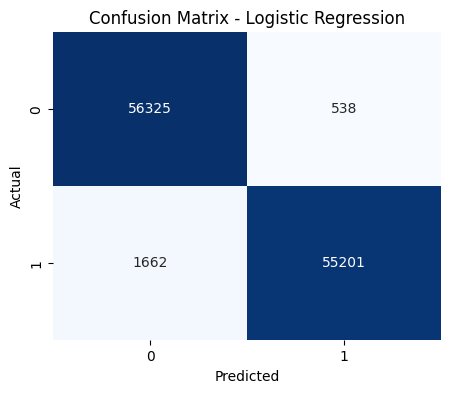


Training with StratifiedKFold + GridSearchCV: Decision Tree
Best Parameters: {'max_depth': None, 'min_samples_split': 2}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       1.00      1.00      1.00     56863

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726

ROC-AUC Score: 0.9985139721787454
Training time: 362.75 seconds


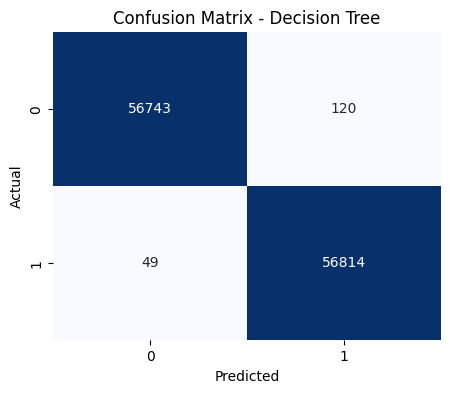


Training with StratifiedKFold + GridSearchCV: Random Forest
Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       1.00      1.00      1.00     56863

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726

ROC-AUC Score: 0.999999451197013
Training time: 1763.81 seconds


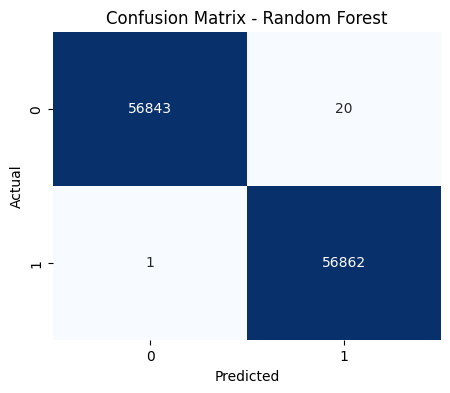

In [6]:
import time
param_grids = {
    "Logistic Regression": {
        "model": LogisticRegression(solver='liblinear', max_iter=1000),
        "params": {
            "C": [0.1, 1, 10],  # fewer values
            "penalty": ["l1", "l2"]
        }
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(),
        "params": {
            "max_depth": [None, 10],  # reduced choices
            "min_samples_split": [2, 5]
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(n_jobs=-1),  # use all cores
        "params": {
            "n_estimators": [50],  # fewer trees
            "max_depth": [None, 10],  # smaller range
            "min_samples_split": [2, 5]
        }
    }
}

# Stratified K-Fold
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

results = {}

for name, cfg in param_grids.items():
    print(f"\nTraining with StratifiedKFold + GridSearchCV: {name}")
    start_time = time.time()

    grid = GridSearchCV(
        estimator=cfg["model"],
        param_grid=cfg["params"],
        scoring="roc_auc",
        cv=skf,
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:, 1]

    # Metrics
    print("Best Parameters:", grid.best_params_)
    print(classification_report(y_test, y_pred))
    roc_score = roc_auc_score(y_test, y_prob)
    print("ROC-AUC Score:", roc_score)
    print(f"Training time: {time.time() - start_time:.2f} seconds")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    results[name] = {
        "model": best_model,
        "best_params": grid.best_params_,
        "roc_auc": roc_score
    }


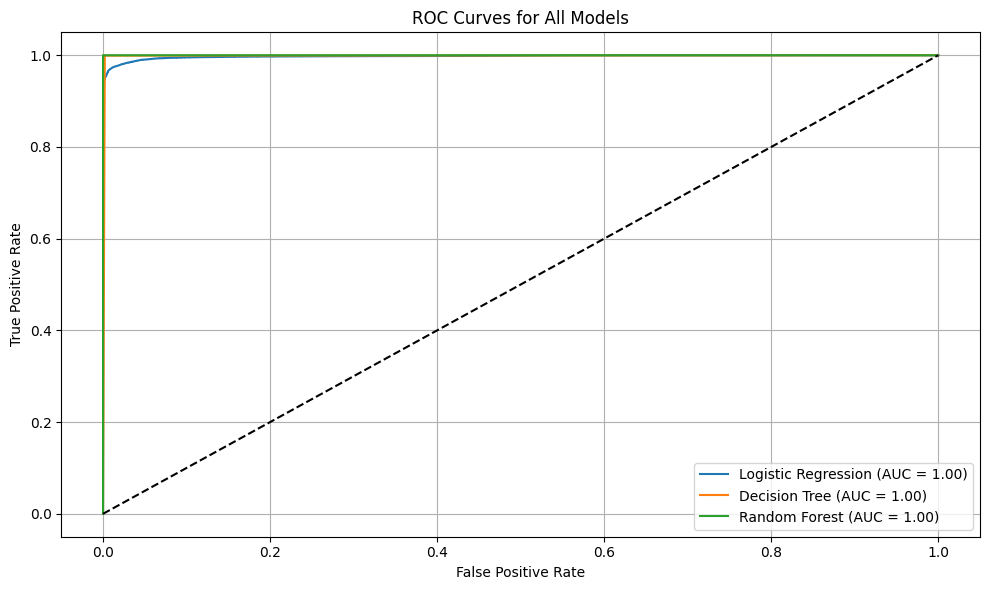

In [9]:
## Step 5: Evaluate Models with ROC Curves
plt.figure(figsize=(10, 6))

for name, result in results.items():
    model = result["model"]
    y_prob = model.predict_proba(X_test)[:, 1]  # Probabilities for ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {result["roc_auc"]:.2f})')

# Baseline (random guessing)
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for All Models')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [10]:
## Step 6: Save the Best Model (Dynamic Selection)
from joblib import dump

# Automatically identify the best model by ROC-AUC
best_model_name = max(results, key=lambda name: results[name]['roc_auc'])
best_model = results[best_model_name]['model']

# Save the best model
file_name = f"best_model_{best_model_name.replace(' ', '_').lower()}.joblib"
dump(best_model, file_name)

print(f"Best Model: {best_model_name}")
print(f"Saved as: {file_name}")


Best Model: Random Forest
Saved as: best_model_random_forest.joblib
